### Question 1
Program the Heavyball Method

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
f = lambda x,y: 100*(y-x**2)**2+(1-x)**2
Df = lambda x,y: np.array([400*x**3-400*x*y-2+2*x,
                           200*y - 200*x**2])
D2g = lambda x,y: np.array([[1200*x**2 - 400*y +2, -400*x],
                            [-400*x, 200]])

In [11]:
from matplotlib.colors import LogNorm  # useful for visualizing this function

def plot_path(path, func, title, window=[-4.5,4.5,-4.5,4.5], contours=np.logspace(-2,6,100), skip=1):
    '''Plots path defined in (N,2) array "path" on a contour plot of "func" in window "window"'''
    plt.figure(figsize=(5,5),dpi=150)
    X = np.linspace(window[0],window[1],300)
    Y = np.linspace(window[2],window[3],300)
    Xmesh, Ymesh = np.meshgrid(X,Y)
    Z = func(Xmesh,Ymesh)
    CS = plt.contourf(Xmesh, Ymesh, Z, contours, cmap='jet', norm = LogNorm())
    # contourf fills the colors. blue is lower value, red is higher value
     
    plt.axis(window)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)

    if path is not None:
        for i in range(path.shape[0]-1): # iterate through steps
            if i%skip==0:
                # only plot arrows every "skip" iterations
                plt.arrow(path[i,0],path[i,1],path[i+1,0]-path[i,0],path[i+1,1]-path[i,1],
                          color='k',length_includes_head=True)
    plt.show() 

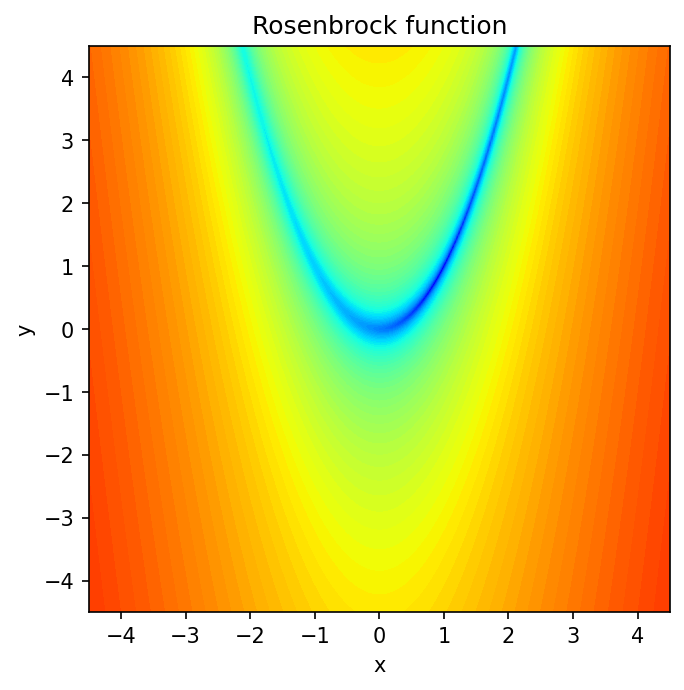

In [12]:
plot_path(None,f,'Rosenbrock function')

In [37]:
D2g(1,1)
eigs, _ = np.linalg.eigh(D2g(1,1))
maxval = eigs[1]
minval = eigs[0]
for i in range(1000):
    x = np.random.uniform(-4.5,4.5,2) # generate a random point
    H = D2g(x[0],x[1])                # and evaluate the Hessian there
    tmp_eigs, _ = np.linalg.eigh(H)
    if tmp_eigs[1]>maxval:                # if eigenvalues larger or smaller, choose those
        maxval = tmp_eigs[1]
    if tmp_eigs[0]<minval:
        minval = tmp_eigs[0]
        
print('Maximum eigenvalue :',maxval,'\nMinimum eigenvalue :',minval)

Maximum eigenvalue : 26034.313774842354 
Minimum eigenvalue : -1585.8887387892491


In [38]:
%%time
x = np.array([-3,-1])
path = [x]
tol = 1e-8
beta = (np.sqrt(maxval)-np.sqrt(eigs[0]))**2/(np.sqrt(maxval)+np.sqrt(eigs[0]))**2  
print('beta = ',beta)
alpha = 4/(np.sqrt(eigs[0])+np.sqrt(maxval))**2                                      
print('alpha = ',alpha)
max_steps = 20000
dx = Df(x[0],x[1])
pk = dx*0      # first update is just gradient descent
i=0
while np.linalg.norm(dx)>tol and i<max_steps:
    pk = -alpha*dx + beta*pk
    xnew = x + pk
    path.append(xnew)
    x = xnew
    i += 1
    dx = Df(x[0],x[1])

path = np.array(path)
print(f'After {i} iterations, approximate minimum is {f(x[0],x[1])} at {x}')

beta =  0.9844555861978365
alpha =  0.00015244689471792422
After 3031 iterations, approximate minimum is 8.39746058177569e-17 at [1.00000001 1.00000002]
CPU times: user 74.4 ms, sys: 15.8 ms, total: 90.2 ms
Wall time: 72.8 ms


### Question 2

a) Compute optimal solution by solving normal equation

In [81]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

data = np.loadtxt("CaCovidInfMarch24toMidJuly.txt")
Xcovid = np.arange(1, len(data) + 1)
linear = LinearRegression()

In [82]:
X_train = Xcovid[0:90].reshape(-1,1)
X_valid = Xcovid[90:120].reshape(-1,1)
y_train = data[0:90]
y_valid = data[90:120]

In [83]:
linear.fit(X_train,y_train)

LinearRegression()

In [84]:
y_predict = linear.predict(X_valid.reshape(-1,1))
y_predict

array([3358.83673473, 3389.00733134, 3419.17792795, 3449.34852455,
       3479.51912116, 3509.68971777, 3539.86031438, 3570.03091099,
       3600.2015076 , 3630.37210421, 3660.54270082, 3690.71329743,
       3720.88389404, 3751.05449065, 3781.22508726, 3811.39568387,
       3841.56628048, 3871.73687709, 3901.9074737 , 3932.0780703 ,
       3962.24866691, 3992.41926352, 4022.58986013, 4052.76045674,
       4082.93105335, 4113.10164996, 4143.27224657, 4173.44284318,
       4203.61343979, 4233.7840364 ])

In [85]:
print(np.sqrt(mean_squared_error(y_train, linear.predict(X_train.reshape(-1,1)))))
print(np.sqrt(mean_squared_error(y_valid, y_predict)))

417.8948376599642
4263.1047860409435


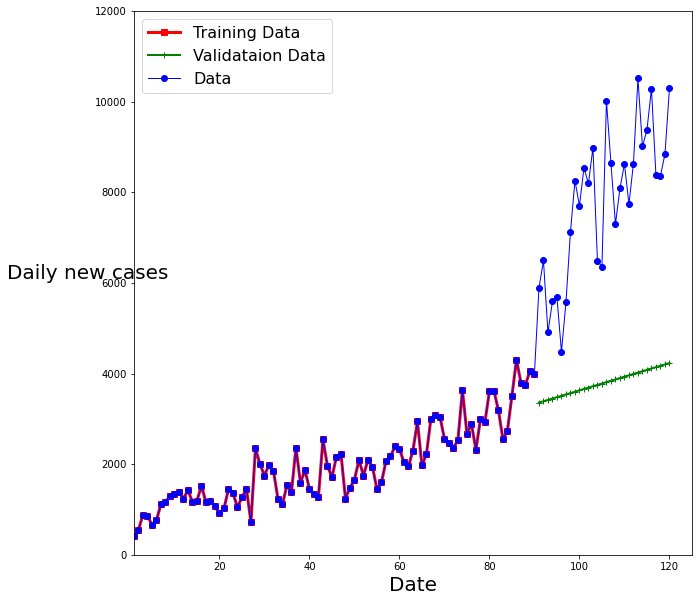

In [24]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

b) compute optimal solution by full batch gradient descent

In [86]:
X_b = np.c_[np.ones((90, 1)), X_train] 
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_train)
theta_best

array([613.31244327,  30.17059661])

In [87]:
X_new_b = np.c_[np.ones((30, 1)), X_valid]
y_predict1 = X_new_b.dot(theta_best)
y_predict1

array([3358.83673473, 3389.00733134, 3419.17792795, 3449.34852455,
       3479.51912116, 3509.68971777, 3539.86031438, 3570.03091099,
       3600.2015076 , 3630.37210421, 3660.54270082, 3690.71329743,
       3720.88389404, 3751.05449065, 3781.22508726, 3811.39568387,
       3841.56628048, 3871.73687709, 3901.9074737 , 3932.0780703 ,
       3962.24866691, 3992.41926352, 4022.58986013, 4052.76045674,
       4082.93105335, 4113.10164996, 4143.27224657, 4173.44284318,
       4203.61343979, 4233.7840364 ])

In [88]:
print(np.sqrt(mean_squared_error(y_valid, y_predict1)))

4263.104786040943


In [445]:
m=120
n_epochs = 50
eta = 0.000001
theta = np.random.randn(2,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(m):
        if epoch == 0 and i < 20: 
            y_predict2 = X_new_b.dot(theta)
            style = "b-" if i > 0 else "r-"
        random_index = np.random.randint(m) 
        xi = X_b[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

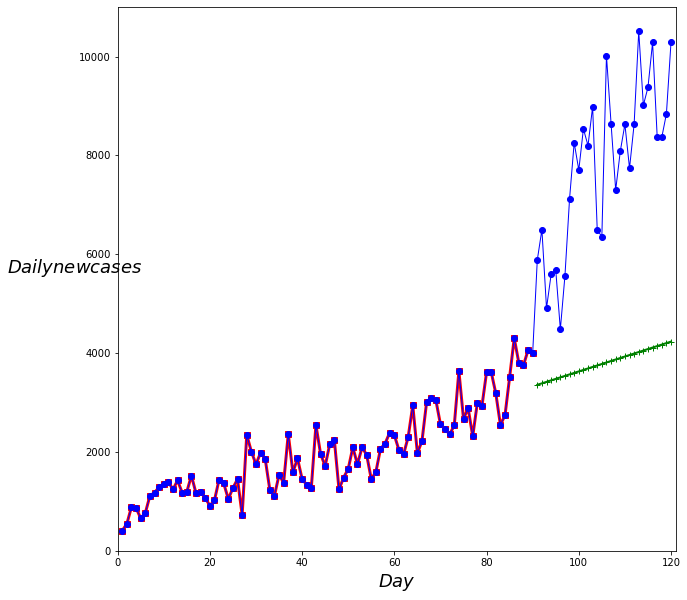

In [446]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict1, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.xlabel("$Day$", fontsize=18)
plt.ylabel("$Daily new cases$", rotation=0, fontsize=18)
plt.axis([0, 121, 0, 11000])
plt.show() 

c) compute optimal solution by mini-batch (size 10) stochastic gradient descent

In [89]:
m=120
n_epochs = 50
eta = 0.001
minibatch_size = 10
theta = np.random.randn(2,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(0, m, minibatch_size):
        if epoch == 0 and i < 20: 
            y_predict3 = X_new_b.dot(theta)
        random_index = np.random.randint(m) 
        xi = X_b[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = (2/minibatch_size) * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

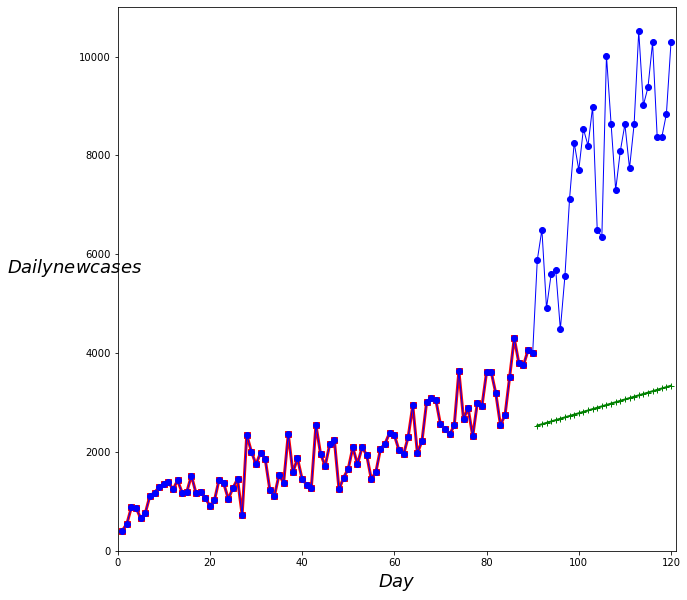

In [452]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict3, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.xlabel("$Day$", fontsize=18)
plt.ylabel("$Daily new cases$", rotation=0, fontsize=18)
plt.axis([0, 121, 0, 11000])
plt.show() 

In [90]:
print(np.sqrt(mean_squared_error(y_valid, y_predict3)))

5708.291632481118


### Question 3

Repeat Problem 2 for quadratic polynomial regressionmodel.

In [91]:
quadratic = PolynomialFeatures(degree = 2)
X_quadratic = quadratic.fit_transform(Xcovid.reshape(-1,1))
X_train1 = X_quadratic[0:90]
X_valid1 = X_quadratic[90:120]
y_train1 = data[0:90]
y_valid1 = data[90:120]

In [92]:
polybig_features = PolynomialFeatures(degree=2,include_bias=False)
std_scaler = StandardScaler()
lin_reg = LinearRegression()
polynomial_regression = Pipeline([
("poly_features", polybig_features),
("std_scaler", std_scaler),
("lin_reg", lin_reg),
])

In [93]:
polynomial_regression.fit(X_train1, y_train1)
y_predict4 = polynomial_regression.predict(X_valid1)
y_predict4

array([4028.9770682 , 4116.17866037, 4205.01872416, 4295.48007132,
       4387.54400669, 4481.1903282 , 4576.3973269 , 4673.14178695,
       4771.3989856 , 4871.14269319, 4972.34517318, 5074.97718214,
       5179.00796973, 5284.4052787 , 5391.13534493, 5499.16289739,
       5608.45115814, 5718.96184235, 5830.65515832, 5943.48980741,
       6057.42298411, 6172.41037599, 6288.40616376, 6405.36302119,
       6523.23211517, 6641.96310571, 6761.5041459 , 6881.80188193,
       7002.80145311, 7124.44649185])

In [94]:
print(np.sqrt(mean_squared_error(y_valid1, y_predict4)))

2564.3061565493117


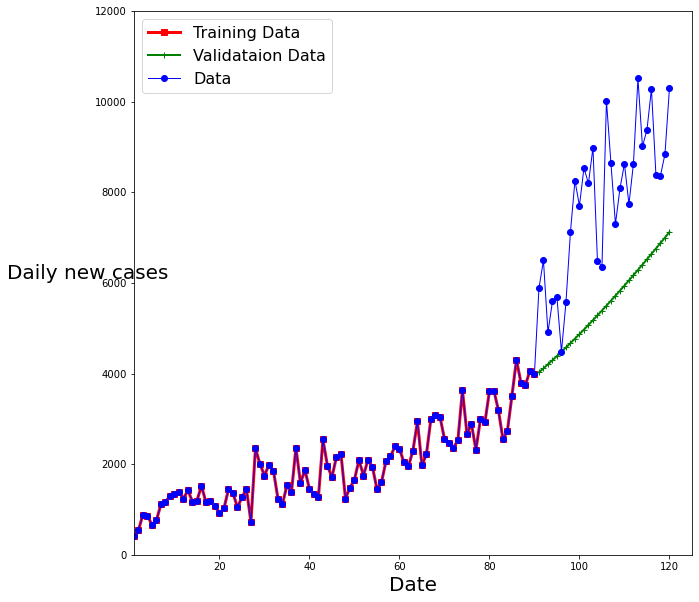

In [106]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict4, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [95]:
theta_best = np.linalg.inv(X_train1.T.dot(X_train1)).dot(X_train1.T).dot(y_train1)
theta_best

array([1.00109376e+03, 4.88051042e+00, 2.77913035e-01])

In [96]:
y_predict5 = X_valid1.dot(theta_best)
y_predict5

array([3746.61805634, 3802.35665217, 3858.65107408, 3915.50132206,
       3972.9073961 , 4030.86929622, 4089.38702241, 4148.46057467,
       4208.08995299, 4268.27515739, 4329.01618786, 4390.3130444 ,
       4452.165727  , 4514.57423568, 4577.53857043, 4641.05873125,
       4705.13471814, 4769.7665311 , 4834.95417013, 4900.69763523,
       4966.9969264 , 5033.85204363, 5101.26298694, 5169.22975632,
       5237.75235177, 5306.83077329, 5376.46502088, 5446.65509454,
       5517.40099428, 5588.70272008])

In [97]:
print(np.sqrt(mean_squared_error(y_valid1, y_predict5)))

3419.616858582474


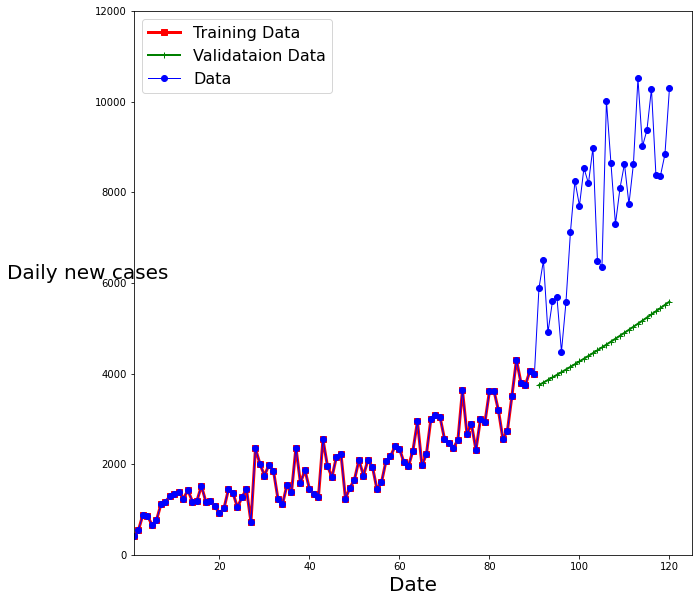

In [105]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict5, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [112]:
m=120
n_epochs = 50
eta = 0.00000001
minibatch_size = 10
theta = np.random.randn(3,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(0, m, minibatch_size):
        if epoch == 0 and i < 20: 
            y_predict6 = X_valid1.dot(theta)
        random_index = np.random.randint(m) 
        xi = X_quadratic[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = (2/minibatch_size) * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

In [113]:
y_predict6

array([[3173.00739885],
       [3244.14422306],
       [3316.06945483],
       [3388.78309417],
       [3462.28514109],
       [3536.57559557],
       [3611.65445762],
       [3687.52172724],
       [3764.17740443],
       [3841.62148918],
       [3919.85398151],
       [3998.87488141],
       [4078.68418887],
       [4159.28190391],
       [4240.66802651],
       [4322.84255668],
       [4405.80549442],
       [4489.55683973],
       [4574.09659262],
       [4659.42475306],
       [4745.54132108],
       [4832.44629667],
       [4920.13967983],
       [5008.62147055],
       [5097.89166885],
       [5187.95027471],
       [5278.79728815],
       [5370.43270915],
       [5462.85653772],
       [5556.06877386]])

In [114]:
print(np.sqrt(mean_squared_error(y_valid1, y_predict6)))

3692.022415590173


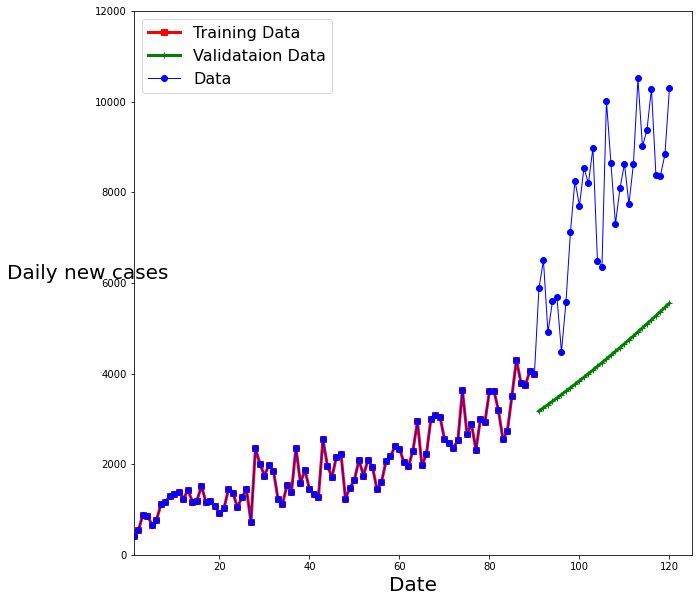

In [115]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict6, "g-+", linewidth=3, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

### Question 4

Repeat Problem 2 for the cubic polynomial regression model

In [208]:
cube = PolynomialFeatures(degree = 3)
X_cube = cube.fit_transform(Xcovid.reshape(-1,1))
X_train2 = X_cube[0:90]
X_valid2 = X_cube[90:120]
y_train2 = data[0:90]
y_valid2 = data[90:120]

In [209]:
polynomial_regression.fit(X_train2, y_train2)
y_predict7 = polynomial_regression.predict(X_valid2)
y_predict7

array([ 4175.06693096,  4311.30451336,  4456.84217935,  4612.35042247,
        4778.53389037,  4956.13230862,  5145.92141113,  5348.71387716,
        5565.36027503,  5796.7500123 ,  6043.81229266,  6307.51707944,
        6588.87606562,  6888.94365059,  7208.81792343,  7549.64165279,
        7912.60328346,  8298.93793949,  8709.9284339 ,  9146.90628507,
        9611.25273969, 10104.39980232, 10627.83127158, 11183.08378293,
       11771.74785811, 12395.46896108, 13055.9485607 , 13754.94519995,
       14494.27557175, 15275.81560141])

In [210]:
print(np.sqrt(mean_squared_error(y_valid2, y_predict7)))

2429.6466082021316


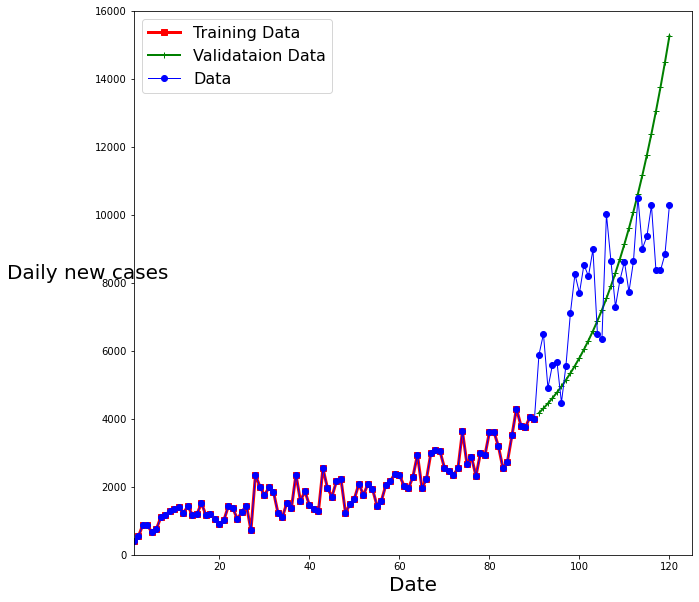

In [211]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict7, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 16000])
plt.show()

In [212]:
theta_best2 = np.linalg.inv(X_train2.T.dot(X_train2)).dot(X_train2.T).dot(y_train2)
theta_best2

array([ 6.53087819e+02,  4.95422479e+01, -9.42304168e-01,  8.93932017e-03])

In [213]:
y_predict8 = X_valid2.dot(theta_best2)
y_predict8

array([4094.62400266, 4196.25349251, 4300.93287877, 4408.71579734,
       4519.65588415, 4633.80677513, 4751.22210618, 4871.95551324,
       4996.06063222, 5123.59109904, 5254.60054963, 5389.1426199 ,
       5527.27094579, 5669.0391632 , 5814.50090806, 5963.70981629,
       6116.71952382, 6273.58366655, 6434.35588042, 6599.08980135,
       6767.83906525, 6940.65730804, 7117.59816566, 7298.71527401,
       7484.06226902, 7673.69278662, 7867.66046271, 8066.01893323,
       8268.82183409, 8476.12280122])

In [257]:
print(np.sqrt(mean_squared_error(y_valid2, y_predict8)))

2080.053019530203


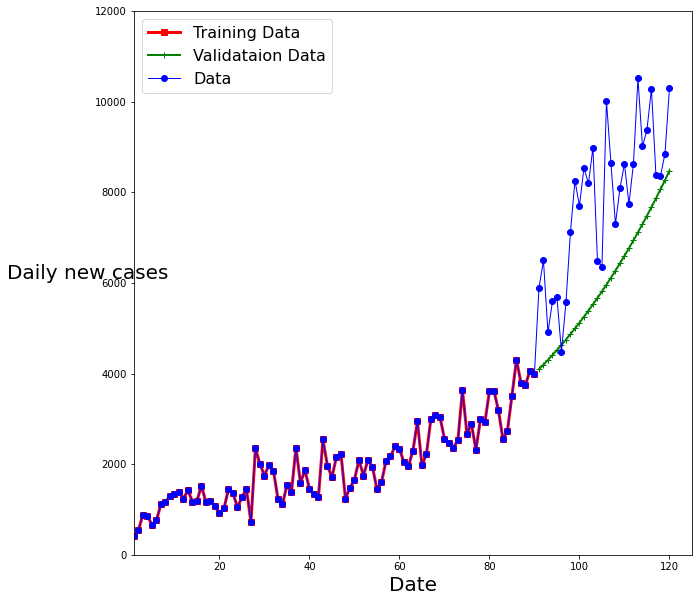

In [258]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict8, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 12000])
plt.show()

In [253]:
m=120
n_epochs = 50
eta = 0.00000000001
minibatch_size = 10
theta = np.random.randn(4,1) 
theta_path_sgd_nols = []
for epoch in range(n_epochs):
    for i in range(0, m, minibatch_size):
        if epoch == 0 and i < 20: 
            y_predict9 = X_valid2.dot(theta)
        random_index = np.random.randint(m) 
        xi = X_cube[random_index:random_index+1]   
        yi = data[random_index:random_index+1]  
        gradients = (2/minibatch_size) * xi.T.dot(xi.dot(theta) - yi) 
        theta = theta - eta * gradients
        theta_path_sgd_nols.append(theta) 

In [254]:
y_predict9

array([[ 8305.98681832],
       [ 8572.91135814],
       [ 8845.50156678],
       [ 9123.8170315 ],
       [ 9407.91733955],
       [ 9697.86207819],
       [ 9993.71083467],
       [10295.52319625],
       [10603.35875019],
       [10917.27708373],
       [11237.33778414],
       [11563.60043867],
       [11896.12463458],
       [12234.96995912],
       [12580.19599955],
       [12931.86234312],
       [13290.02857708],
       [13654.7542887 ],
       [14026.09906523],
       [14404.12249392],
       [14788.88416204],
       [15180.44365683],
       [15578.86056554],
       [15984.19447545],
       [16396.50497379],
       [16815.85164784],
       [17242.29408483],
       [17675.89187204],
       [18116.7045967 ],
       [18564.79184609]])

In [255]:
print(np.sqrt(mean_squared_error(y_valid1, y_predict9)))

5599.80626839339


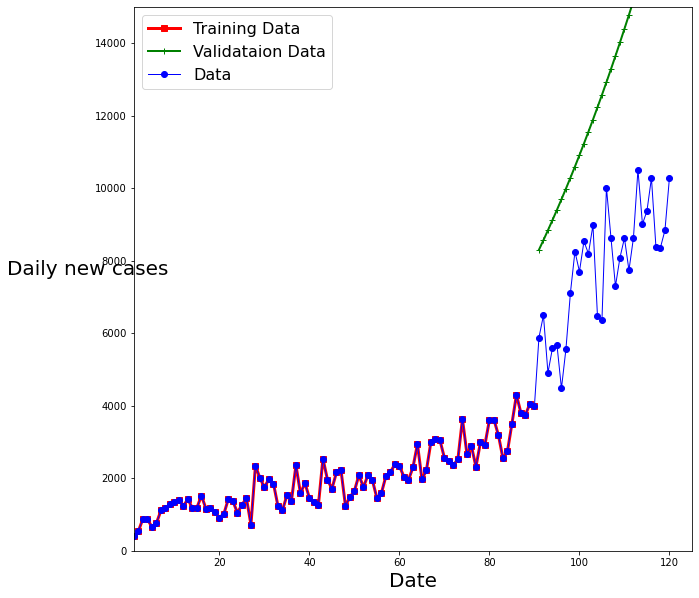

In [256]:
plt.figure(figsize=(10,10))
plt.plot(X_train,y_train, "r-s", linewidth=3,label="Training Data")
plt.plot(X_valid,y_predict9, "g-+", linewidth=2, label="Validataion Data")
plt.plot(Xcovid,data, "b-o", linewidth=1, label="Data")
plt.legend(loc="upper left", fontsize=16)
plt.xlabel(r"Date", fontsize=20)
plt.ylabel(r"Daily new cases ", fontsize=20, rotation=0)
plt.axis([1, 125, 0, 15000])
plt.show()

### Question 5

Most of the models underfitted the daily new casses of Covid-19 for California from March to July, only Mini-batch stochastic gradient descent with cubic polynomial regression seems to overfit the data. From these graph, the most reliable one is probably the cube polynomial regression, by increasing the degree, the model seems to fit better. 